____
# INTERPOLATE AND ROTATE SWOT DATA ON COLOC POINTS

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import dask.dataframe as dd
import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import (
    browse_swot_2km,
    add_mask_inside_swot,
    add_grid_metrics,
    build_swath_polygon,
)

# from diagnosis import drifters_sources

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine


In [2]:
if True:
    from dask.distributed import Client
    from dask_jobqueue import PBSCluster
    from dask import config

    config.set({"distributed.comm.timeouts.connect": "200s"})
    cluster = PBSCluster(cores=28, processes=28, walltime="02:00:00")
    # cluster = PBSCluster(cores=20, processes=20, walltime='02:00:00')#8
    w = cluster.scale(jobs=1)
else:
    from dask.distributed import Client, LocalCluster

    cluster = LocalCluster()

client = Client(cluster)
client

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask_jobqueue/core.py:237: FutureWarning: extra has been renamed to worker_extra_args. You are still using it (even if only set to []; please also check config files). If you did not set worker_extra_args yet, extra will be respected for now, but it will be removed in a future release. If you already set worker_extra_args, extra is ignored and you can remove it.
  w

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: http://10.148.0.65:8787/status,
Dashboard: http://10.148.0.65:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.148.0.65:45929,Workers: 0
Dashboard: http://10.148.0.65:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [14]:
cluster.close()

_______________
# CHOOSE coloc sources

In [3]:
drifters_sources = "all_med_variational_10min_v1.nc"

# Drifters param
# dt = '10d'
dt = "12h"
drifter_preprocess = "spectral_decomp"  # '', 'spectral_decomp', 'low_pass'

if drifter_preprocess == True:
    drifters_sources = "spectral_decomp_" + drifters_sources

colocs_source = f"{dt}_{drifter_preprocess}_{drifters_sources}".replace(".nc", ".csv")

# Drifters
ddf = (
    dd.read_csv(
        os.path.join(
            zarr_dir, "coloc_files", "drifters", f"drifterscoloc_" + colocs_source
        ),
        dtype={"drifter_id": str},
        parse_dates=["datetime"],
    )
    .set_index("row_number")
    .repartition(npartitions=56)
)

ddf = ddf[
    (~((ddf.pass_number == 3) & (ddf.cycle_number == 568)))
    & (
        ~(
            (ddf.pass_number == 16)
            & (
                (ddf.cycle_number == 508)
                | (ddf.cycle_number == 513)
                | (ddf.cycle_number == 534)
                | (ddf.cycle_number == 554)
                | (ddf.cycle_number == 568)
            )
        )
    )
].persist()

df = ddf.compute()

_________
# Functions

In [5]:
ggd_variables = [
    "cvl_mean_dynamic_topography_cnes_cls_22",
    "cvl_mean_sea_surface_cnes_22_hybrid",
    "cvl_ocean_tide_fes_2022",
    "cvl_ssha_reference",
    "duacs_ssha_karin_2_calibrated",
    "duacs_ssha_karin_2_filtered",
]


variables = [  #'ancillary_surface_classification_flag',
    "cross_track_distance",
    "distance_to_coast",
    "duacs_editing_flag",
    #'duacs_phase_screen',
    #'duacs_phase_screen_orbit',
    #'duacs_phase_screen_static',
    "duacs_relative_vorticity",
    "duacs_speed_meridional",
    "duacs_speed_meridional_abs",
    "duacs_speed_zonal",
    "duacs_speed_zonal_abs",
    "duacs_strain",
    "duacs_xcal",
    "sig0_karin_2",
    "phi",
    "swh_model",
    "ssh_karin_uncert",
    "pass_number",
]

# For swot 2km interp on the cycle
from swot import interp_dss, rotate


def interp_coloc_one_cycle(dfr_, dsalti):  # , vars_to_rotate=[]):
    cycle = dfr_.cycle_number.values.mean()
    print(cycle)

    if "cycle_number" in dsalti:
        dsalti_ = dsalti.sel(cycle_number=cycle)
    else:
        dsalti_ = dsalti

    # ATTENTION : NEED TO REMOVE VARIABLES FOR WHICH LONGITUDE, LATITUDE ARE NOT COORDS
    dropv = []
    if "pass_number" in dsalti_.keys():
        dropv += ["pass_number"]
    if "cycle_number" in dsalti_.keys():
        dropv += ["cycle_number"]
    if "npts" in dsalti_.keys():
        dropv += ["npts"]
    if "cutoff" in dsalti_.keys():
        dropv += ["cutoff"]

    df_interp = interp_dss(
        dsalti_.drop_vars(dropv), dfr_.longitude.values, dfr_.latitude.values
    )
    df_out = (
        pd.concat(
            [
                dfr_.reset_index()[["row_number", "longitude"]].set_index("longitude"),
                df_interp.set_index("longitude"),
            ],
            axis=1,
        )
        .reset_index()
        .set_index("row_number")
    )
    # for v in vars_to_rotate :
    #    df_out[v[O]], df_out[v[1]] = rotate(df_out[v[O]], df_out[v[1]], df_out(phi))
    return df_out


# For swot 2km on cycle time
def coloc_swot2km_cycle(dfr, dsalti):
    meta = interp_coloc_one_cycle(dfr[dfr.cycle_number == 531].compute(), dsalti)

    df_out = dfr.groupby("cycle_number").apply(
        interp_coloc_one_cycle, dsalti, meta=meta
    )

    if "npts" in dsalti.keys():
        df_out["npts"] = dsalti.npts.values
    if "cutoff" in dsalti.keys():
        df_out["cutoff"] = int(dsalti.cutoff.values)
    return df_out


# For L4 interpolated at drifter time
def coloc_L4_drifter_time(dfr, dsalti):
    lon = df.longitude.values
    lat = df.latitude.values
    t = pd.to_datetime(df.datetime).values
    ds0 = dsalti.interp(longitude=("z", lon), latitude=("z", lat), time=("z", t))
    df0 = ds0.to_dataframe()
    df0.index.names = ["row_number"]
    return df0


# For L4 interpolated at swot
def coloc_L4_swot_time(dfr, dsalti):
    lon = df.longitude.values
    lat = df.latitude.values
    t = pd.to_datetime(df.cycle_date).values
    ds0 = dsalti.interp(longitude=("z", lon), latitude=("z", lat), time=("z", t))
    df0 = ds0.to_dataframe()
    df0.index.names = ["row_number"]
    return df0

___________
# Find all L4 files

In [ ]:
alti_files = glob(os.path.join(zarr_dir, "before_coloc", "L4_sealevel", "*"))
alti_files

In [7]:
# drifter time
for f in alti_files:
    dsalti = xr.open_dataset(f)
    dfout = coloc_L4_drifter_time(df, dsalti)
    path = os.path.join(
        zarr_dir,
        "coloc_files",
        "alti",
        "alticoloc_" + f.split("/")[-1].replace(".nc", "_" + colocs_source),
    )
    dfout.to_csv(path)
    print(path)

/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/coloc_files/alti/alticoloc_L4_noswot_regional_10d_spectral_decomp_all_med_variational_10min_v1.csv
/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/coloc_files/alti/alticoloc_L4_withnadirswot_10d_spectral_decomp_all_med_variational_10min_v1.csv
/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/coloc_files/alti/alticoloc_L4_noswot_global_10d_spectral_decomp_all_med_variational_10min_v1.csv


In [7]:
# SWOT time
for f in alti_files:
    dsalti = xr.open_dataset(f)
    dfout = coloc_L4_swot_time(df, dsalti)
    path = os.path.join(
        zarr_dir,
        "coloc_files",
        "alti",
        "alticoloc_" + f.split("/")[-1].replace(".nc", "_swottime_" + colocs_source),
    )
    dfout.to_csv(path)
    print(path)

/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/coloc_files/alti/alticoloc_L4_noswot_regional_swottime_10d_spectral_decomp_all_med_variational_10min_v1.csv
/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/coloc_files/alti/alticoloc_L4_withnadirswot_swottime_10d_spectral_decomp_all_med_variational_10min_v1.csv
/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/coloc_files/alti/alticoloc_L4_noswot_global_swottime_10d_spectral_decomp_all_med_variational_10min_v1.csv


___________
# Find all preprocessed swot-2km files

In [6]:
alti_files = glob(
    os.path.join(zarr_dir, "before_coloc", "preprocessed_swot", "swot2km", "*", "*")
)
alti_files = [f.replace("pass3", "pass*") for f in alti_files if "pass3" in f]
#alti_files = [f for f in alti_files if ("general" in f) | ("diff_only" in f)]
alti_files = sorted([f for f in alti_files if '/gaussian_nb/' in f])
# alti_files = [f for f in alti_files if '/xarray_diff' in f]
alti_files

['/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/gaussian_nb/pass*_swot2km_gaussian_nb_10000.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/gaussian_nb/pass*_swot2km_gaussian_nb_110000.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/gaussian_nb/pass*_swot2km_gaussian_nb_140000.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/gaussian_nb/pass*_swot2km_gaussian_nb_170000.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/gaussian_nb/pass*_swot2km_gaussian_nb_20000.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/gaussian_nb/pass*_swot2km_gaussian_nb_200000.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/ga

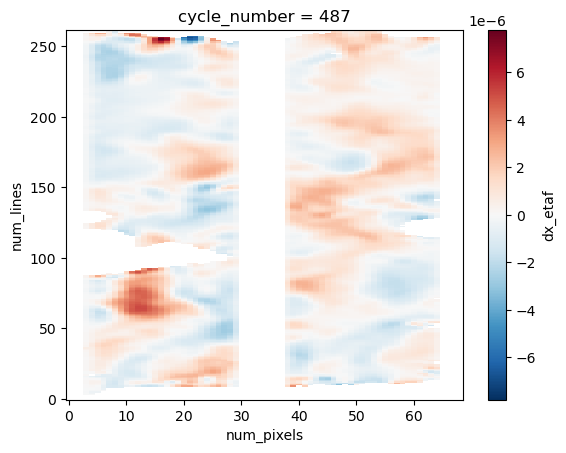

In [9]:
f = glob(alti_files[1])[0]
ds =xr.open_dataset(f)
ds.dx_etaf.isel(cycle_number=10).plot()

# Interpolate with the data of the nearest cycle


In [7]:
for i in range(len(alti_files)):

    path = (
        alti_files[i]
        .replace("/".join(alti_files[i].split("/")[6:10]), "coloc_files/alti")
        .replace("pass*", "alticoloc")
        .replace(".nc", "_" + colocs_source)
    )
    if os.path.isfile(path) :
       print(f'file already exists : {path}')
       continue

    # Alti files
    files = glob(alti_files[i])
    D = []  # for over pass_number
    for f in files:
        try:
            dsalti = xr.open_dataset(f).compute()
            if "phi" in dsalti.variables:
                dsalti = dsalti.reset_coords(["phi", "dx", "dy"])
            pass_number = dsalti.pass_number.values
            print(pass_number)
            ddf_ = ddf[ddf.pass_number == pass_number].persist()
            df_out = (
                coloc_swot2km_cycle(ddf_, dsalti)
                .compute()
                .reset_index()
                .set_index("row_number")
                .sort_index()
            )
            df_out["pass_number"] = int(pass_number)
            D.append(df_out)
        except:
            assert False, f"pb with {f}"
    pd.concat(D, axis=0).to_csv(path)
    print(path)

3
531.0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 506.26 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


16
531.0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 333.80 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/coloc_files/alti/alticoloc_swot2km_gaussian_nb_10000_12h_spectral_decomp_all_med_variational_10min_v1.csv
16
531.0


...

/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/coloc_files/alti/alticoloc_swot2km_gaussian_nb_50000_12h_spectral_decomp_all_med_variational_10min_v1.csv
3
531.0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 506.26 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


16
531.0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 333.80 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/coloc_files/alti/alticoloc_swot2km_gaussian_nb_80000_12h_spectral_decomp_all_med_variational_10min_v1.csv


In [10]:
path

'/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/coloc_files/alti/alticoloc_swot2km_gaussian_2times1D_80000_12h_spectral_decomp_all_med_variational_10min_v1.csv'

______________________
# Find L3-250m

In [6]:
alti_dir = glob(
    os.path.join(zarr_dir, "before_coloc", "preprocessed_swot", "swot250m", "*", "*")
)
# alti_files = [f.replace('pass3', 'pass*') for f in alti_files if 'pass3' in f]
alti_dir = np.unique(["/".join(f.split("/")[:-1]) for f in alti_dir])
# alti_dir = [f for f in alti_dir if ('general' in f)|('diff_only' in f)]
alti_dir = [f for f in alti_dir if "xarray_diff" in f]
alti_dir

['/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot250m/xarray_diff']

In [7]:
def wrapper_interp_one_cycle(df, dir_):
    # print(list(df.keys()))
    swath = int(df.reset_index().pass_number.mean())
    cycle = int(df.reset_index().cycle_number.mean())
    path = os.path.join(dir_, f"{int(swath)}_{int(cycle)}.nc")
    try:
        dsalti = xr.open_dataset(path)
        dsalti["cycle_number"] = cycle
        dsalti = dsalti.set_coords("cycle_number").expand_dims("cycle_number")
        if "phi" in dsalti:
            dsalti = dsalti.reset_coords(["phi"])
    except:
        assert False, path
    dfout = interp_coloc_one_cycle(df, dsalti)
    return dfout


dir_ = alti_dir[-1]
dfr = df.where((df.pass_number == 3) & (df.cycle_number == 531)).dropna().iloc[0:100]
meta = dfr.groupby(["pass_number", "cycle_number"]).apply(
    wrapper_interp_one_cycle, dir_
)
meta

531.0


/dev/shm/pbs.3491409.datarmor0/ipykernel_19920/3410752675.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  meta = dfr.groupby(['pass_number', 'cycle_number']).apply(wrapper_interp_one_cycle, dir_)


longitude   latitude      etaf  \
pass_number cycle_number row_number                                   
3.0         531.0        183498       4.495395  39.116744 -0.128129   
                         183499       4.495224  39.117389 -0.127861   
                         183500       4.495039  39.118049 -0.127798   
                         183501       4.494844  39.118723 -0.127904   
                         183502       4.494639  39.119412 -0.127743   
...                                        ...        ...       ...   
                         183593       4.443335  39.176501 -0.125088   
                         183594       4.442875  39.176580 -0.125053   
                         183595       4.442400  39.176627 -0.125057   
                         183596       4.441909  39.176642 -0.125071   
                         183597       4.441401  39.176626 -0.125068   

                                          dx_etaf   dy_etaf      dxx_etaf  \
pass_number cycle_number row_number                                         
3.0         531.0        183498      3.991977e-06  0.000004 -2.137109e-10   
                         183499      4.035726e-06  0.000003 -5.775159e-10   
                         183500      4.068751e-06  0.000003 -4.148043e-10   
                         183501      4.135148e-06  0.000003 -1.231356e-10   
                         183502      4.059837e-06  0.000003  3.906714e-10   
...                                           ...       ...           ...   
                         183593     -3.854768e-07  0.000002 -1.220897e-10   
                         183594     -3.762422e-07  0.000002 -3.714844e-10   
                         183595     -3.743195e-07  0.000002 -4.898410e-10   
                         183596     -3.474697e-07  0.000002 -5.200176e-10   
                         183597     -3.219573e-07  0.000002 -3.771205e-10   

                                         dyy_etaf      dxy_etaf      etac  \
pass_number cycle_number row_number                                         
3.0         531.0        183498     -2.926475e-09  7.986678e-10 -0.124483   
                         183499     -2.812393e-09  4.814497e-10 -0.125566   
                         183500     -2.364668e-09  1.262768e-10 -0.127489   
                         183501     -1.593931e-09 -2.895887e-10 -0.130719   
                         183502     -3.664939e-10 -8.627175e-10 -0.132492   
...                                           ...           ...       ...   
                         183593     -1.269173e-09  9.160627e-11 -0.126629   
                         183594     -1.574113e-09  8.836865e-11 -0.124858   
                         183595     -1.703269e-09  3.505210e-11 -0.123369   
                         183596     -1.636883e-09  8.571395e-12 -0.123147   
                         183597     -1.431040e-09 -1.096827e-11 -0.124156   

                                      dx_etac   dy_etac      dxx_etac  \
pass_number cycle_number row_number                                     
3.0         531.0        183498      0.000021  0.000003 -6.922082e-08   
                         183499      0.000030 -0.000018 -4.951740e-08   
                         183500      0.000028 -0.000019 -2.244746e-08   
                         183501      0.000024 -0.000018  2.578316e-08   
                         183502      0.000008 -0.000008  6.089851e-08   
...                                       ...       ...           ...   
                         183593     -0.000018 -0.000006 -2.587175e-08   
                         183594     -0.000016 -0.000009 -3.440171e-08   
                         183595     -0.000015 -0.000010 -4.718593e-08   
                         183596     -0.000012 -0.000006 -5.119104e-08   
                         183597     -0.000009 -0.000003 -3.777354e-08   

                                         dyy_etac      dxy_etac  
pass_number cycle_number row_number                              
3.0         531.0        18

In [8]:
for dir_ in alti_dir:
    path = (
        dir_.replace("before_coloc/preprocessed_swot", "coloc_files/alti").replace(
            "swot250m/", "alticoloc_swot250m_"
        )
        + "_"
        + colocs_source
    )
    # if os.path.isfile(path) : continue

    dfr = (
        df.where((df.pass_number == 3) & (df.cycle_number == 500)).dropna().iloc[0:100]
    )
    meta = dfr.groupby(["pass_number", "cycle_number"], observed=True).apply(
        wrapper_interp_one_cycle, dir_
    )

    df_out = (
        ddf.groupby(["pass_number", "cycle_number"], observed=True)
        .apply(wrapper_interp_one_cycle, dir_, meta=meta)
        .reset_index()
        .compute()
    )
    path = (
        dir_.replace("before_coloc/preprocessed_swot", "coloc_files/alti").replace(
            "swot250m/", "alticoloc_swot250m_"
        )
        + "_"
        + colocs_source
    )
    df_out.to_csv(path)
    print(path)

500.0


/dev/shm/pbs.3491409.datarmor0/ipykernel_19920/3105113041.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  meta = dfr.groupby(['pass_number', 'cycle_number'], observed=True).apply(wrapper_interp_one_cycle, dir_)


/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/coloc_files/alti/alticoloc_swot250m_xarray_diff_12h_spectral_decomp_all_med_variational_10min_v1.csv


In [20]:
path = "/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/coloc_files/alti/alticoloc_swot250m_general_12h_spectral_decomp_all_med_variational_10min_v0.csv"
df = pd.read_csv(path)
df.columns

Index(['Unnamed: 0', 'pass_number', 'cycle_number', 'row_number', 'longitude',
       'latitude', 'ancillary_surface_classification_flag',
       'cross_track_distance', 'distance_to_coast', 'duacs_editing_flag',
       'duacs_phase_screen', 'duacs_phase_screen_orbit',
       'duacs_phase_screen_static', 'duacs_relative_vorticity',
       'duacs_speed_meridional', 'duacs_speed_meridional_abs',
       'duacs_speed_zonal', 'duacs_speed_zonal_abs', 'duacs_strain',
       'duacs_xcal', 'sig0_karin_2', 'phi', 'swh_model'],
      dtype='object')

In [12]:
dfr.pass_number

row_number
53513    3.0
53514    3.0
53515    3.0
53516    3.0
53517    3.0
        ... 
53608    3.0
53609    3.0
53610    3.0
53611    3.0
53612    3.0
Name: pass_number, Length: 100, dtype: float64